In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../datasets/EVProject_dataset.csv")
print(df.shape)
df.head()

(149084, 30)


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [3]:
df.columns.tolist()

['Timestamp',
 'SoC',
 'SoH',
 'Battery_Voltage',
 'Battery_Current',
 'Battery_Temperature',
 'Charge_Cycles',
 'Motor_Temperature',
 'Motor_Vibration',
 'Motor_Torque',
 'Motor_RPM',
 'Power_Consumption',
 'Brake_Pad_Wear',
 'Brake_Pressure',
 'Reg_Brake_Efficiency',
 'Tire_Pressure',
 'Tire_Temperature',
 'Suspension_Load',
 'Ambient_Temperature',
 'Ambient_Humidity',
 'Load_Weight',
 'Driving_Speed',
 'Distance_Traveled',
 'Idle_Time',
 'Route_Roughness',
 'RUL',
 'Failure_Probability',
 'Maintenance_Type',
 'TTF',
 'Component_Health_Score']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149084 entries, 0 to 149083
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               149084 non-null  str    
 1   SoC                     149084 non-null  float64
 2   SoH                     149084 non-null  float64
 3   Battery_Voltage         149084 non-null  float64
 4   Battery_Current         149084 non-null  float64
 5   Battery_Temperature     149084 non-null  float64
 6   Charge_Cycles           149084 non-null  float64
 7   Motor_Temperature       149084 non-null  float64
 8   Motor_Vibration         149084 non-null  float64
 9   Motor_Torque            149084 non-null  float64
 10  Motor_RPM               149084 non-null  float64
 11  Power_Consumption       149084 non-null  float64
 12  Brake_Pad_Wear          149084 non-null  float64
 13  Brake_Pressure          149084 non-null  float64
 14  Reg_Brake_Efficiency    149084 

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["RUL"].describe()

count    149084.000000
mean        216.326154
std          84.653478
min           0.000148
25%         211.659783
50%         241.173600
75%         270.561086
max         299.999891
Name: RUL, dtype: float64

In [8]:
df['Failure_Probability'].value_counts()

Failure_Probability
0    134330
1     14754
Name: count, dtype: int64

In [9]:
df["Component_Health_Score"].describe()

count    149084.000000
mean          0.744538
std           0.264907
min           0.000005
25%           0.735138
50%           0.823353
75%           0.911847
max           0.999999
Name: Component_Health_Score, dtype: float64

Text(0.5, 0, 'Component_Health_Score')

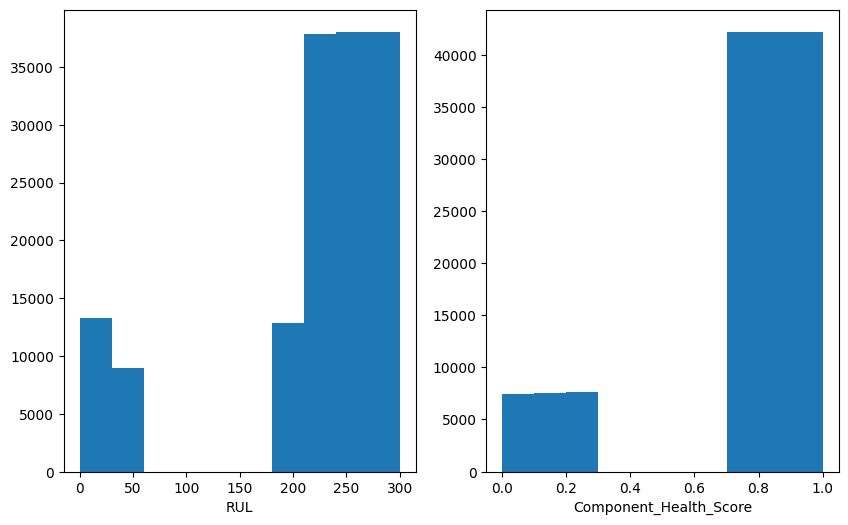

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df['RUL'])
plt.xlabel("RUL")
plt.subplot(1,2,2)
plt.hist(df['Component_Health_Score'])
plt.xlabel("Component_Health_Score")

In [19]:
corr = df.corr(numeric_only=True)

In [20]:
corr["RUL"].sort_values(ascending=False)

RUL                       1.000000
Charge_Cycles             0.005129
Load_Weight               0.004475
Distance_Traveled         0.003361
Battery_Voltage           0.003045
Driving_Speed             0.002648
Power_Consumption         0.002479
Brake_Pad_Wear            0.002446
Component_Health_Score    0.002389
TTF                       0.002175
Failure_Probability       0.001720
Idle_Time                 0.001122
Suspension_Load           0.000640
Motor_RPM                 0.000543
Motor_Temperature        -0.000148
Ambient_Temperature      -0.000177
Tire_Pressure            -0.000678
SoH                      -0.000924
SoC                      -0.001215
Reg_Brake_Efficiency     -0.001263
Brake_Pressure           -0.001529
Ambient_Humidity         -0.001738
Motor_Torque             -0.001880
Maintenance_Type         -0.001943
Motor_Vibration          -0.002179
Tire_Temperature         -0.002245
Battery_Current          -0.002620
Battery_Temperature      -0.004313
Route_Roughness     

In [21]:
corr["Failure_Probability"].sort_values(ascending=False)

Failure_Probability       1.000000
SoC                       0.005144
Maintenance_Type          0.003579
Motor_RPM                 0.002752
Motor_Vibration           0.002544
Idle_Time                 0.002501
Ambient_Humidity          0.001881
RUL                       0.001720
Suspension_Load           0.001344
Distance_Traveled         0.001280
Battery_Temperature       0.000814
Battery_Voltage           0.000149
Tire_Temperature         -0.000474
TTF                      -0.000754
Power_Consumption        -0.000973
Ambient_Temperature      -0.001076
Load_Weight              -0.001108
Brake_Pad_Wear           -0.001147
Driving_Speed            -0.001221
Component_Health_Score   -0.001301
SoH                      -0.001312
Motor_Torque             -0.001739
Charge_Cycles            -0.002024
Motor_Temperature        -0.002351
Tire_Pressure            -0.002701
Reg_Brake_Efficiency     -0.002740
Brake_Pressure           -0.002774
Battery_Current          -0.003256
Route_Roughness     

In [22]:
corr["Component_Health_Score"].sort_values(ascending=False)

Component_Health_Score    1.000000
Tire_Pressure             0.005396
Charge_Cycles             0.004976
Motor_Temperature         0.004380
Battery_Temperature       0.003759
Battery_Voltage           0.003130
Distance_Traveled         0.002608
Reg_Brake_Efficiency      0.002511
Maintenance_Type          0.002390
RUL                       0.002389
Battery_Current           0.002147
Ambient_Humidity          0.001824
Tire_Temperature          0.001711
TTF                       0.001149
Motor_Vibration          -0.000303
Motor_RPM                -0.000610
Driving_Speed            -0.000741
Suspension_Load          -0.000752
Load_Weight              -0.001120
Idle_Time                -0.001125
Failure_Probability      -0.001301
Ambient_Temperature      -0.001382
Brake_Pad_Wear           -0.001711
SoH                      -0.001857
Route_Roughness          -0.002357
SoC                      -0.002647
Power_Consumption        -0.003058
Brake_Pressure           -0.005659
Motor_Torque        